# Simple Linear Regression

## 1. Nạp thư viện

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Nạp dữ liệu vào

In [ ]:
dataset = pd.read_csv('/content/Data_demo.csv')
dataset.head(5)

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [ ]:
dataset.describe(include='all')

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


## 3. Tách biến độc lập và biến phụ thuộc

In [ ]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values
print(X)

[[ 1.1]
 [ 1.3]
 [ 1.5]
 [ 2. ]
 [ 2.2]
 [ 2.9]
 [ 3. ]
 [ 3.2]
 [ 3.2]
 [ 3.7]
 [ 3.9]
 [ 4. ]
 [ 4. ]
 [ 4.1]
 [ 4.5]
 [ 4.9]
 [ 5.1]
 [ 5.3]
 [ 5.9]
 [ 6. ]
 [ 6.8]
 [ 7.1]
 [ 7.9]
 [ 8.2]
 [ 8.7]
 [ 9. ]
 [ 9.5]
 [ 9.6]
 [10.3]
 [10.5]]


In [ ]:
print(y)

[ 39343.  46205.  37731.  43525.  39891.  56642.  60150.  54445.  64445.
  57189.  63218.  55794.  56957.  57081.  61111.  67938.  66029.  83088.
  81363.  93940.  91738.  98273. 101302. 113812. 109431. 105582. 116969.
 112635. 122391. 121872.]


## Chia dữ liệu thành tập huấn luyện và tập kiểm thử

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [ ]:
print(X_train.shape)

(24, 1)


## 5. Trực quan hóa dữ liệu tập huấn luyện X_train, y_train và tập kiểm thử

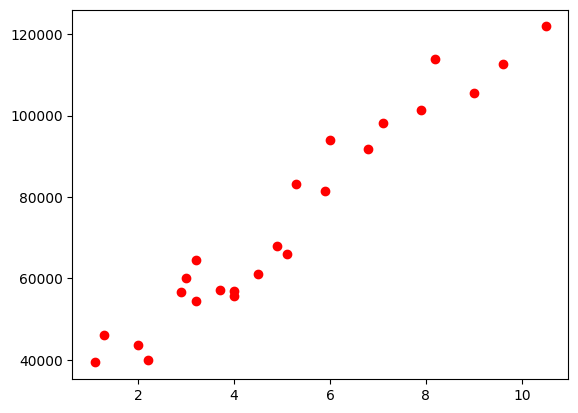

In [ ]:
plt.scatter(X_train, y_train, color='red')
plt.show()

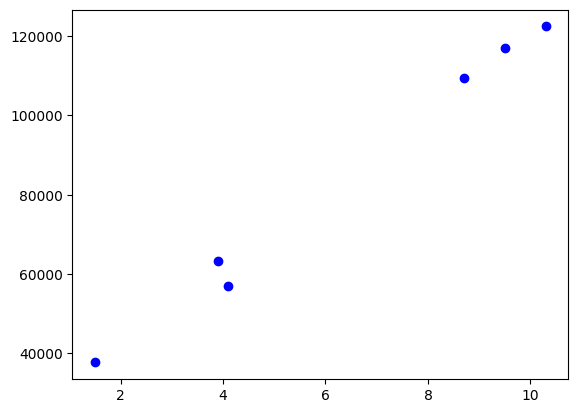

In [ ]:
plt.scatter(X_test,y_test,color='blue')
plt.show()

## 6. Huấn luyện mô hình hồi quy

In [ ]:
#c1 sử dụng thư viện
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train,y_train)

LinearRegression()

In [ ]:
b0 = regressor.intercept_
b1 = regressor.coef_
print(b0)
print(b1)

26780.09915062818
[9312.57512673]


y_hat = 26780.09915062818+ 9312.57512673*X


In [ ]:
#với số năm kinh nghiệm 3.2
y_hat = 26780.09915062818+ 9312.57512673*3.2
print(y_hat)
#c2 dùng phương thức predict
y_hat = regressor.predict([[3.2]])
print(y_hat)

56580.33955616418
[56580.33955616]


In [ ]:
y_pred = regressor.predict(X_test)
print(y_pred)

[ 40748.96184072 122699.62295594  64961.65717022  63099.14214487
 115249.56285456 107799.50275317]


Cách 2 : Sử dụng công thức nhân ma trận

In [ ]:
X_train_c2 = X_train.copy()
X_test_c2 = X_test.copy()

In [ ]:
#chuyển y_train thành ma trận
y_train_c2 = y_train.reshape(-1,1)
y_test_c2 = y_test.reshape(-1,1)

In [ ]:
#tạo vector 1
vector_1 = np.ones((X_train_c2.shape[0] , 1 ))
X_train_bar = np.concatenate((vector_1,X_train_c2),axis=1)
print(x_train_bar)

[[ 1.   9.6]
 [ 1.   4. ]
 [ 1.   5.3]
 [ 1.   7.9]
 [ 1.   2.9]
 [ 1.   5.1]
 [ 1.   3.2]
 [ 1.   4.5]
 [ 1.   8.2]
 [ 1.   6.8]
 [ 1.   1.3]
 [ 1.  10.5]
 [ 1.   3. ]
 [ 1.   2.2]
 [ 1.   5.9]
 [ 1.   6. ]
 [ 1.   3.7]
 [ 1.   3.2]
 [ 1.   9. ]
 [ 1.   2. ]
 [ 1.   1.1]
 [ 1.   7.1]
 [ 1.   4.9]
 [ 1.   4. ]]


In [ ]:
A = np.dot(X_train_bar.T,X_train_bar)
B = np.dot(X_train_bar.T,y_train_c2)
w = np.dot(np.linalg.pinv(A),B) #A-1 * B
print(w)

[[26780.09915063]
 [ 9312.57512673]]


## 7. Trực quan hóa hồi quy trên tập huấn luyện và kiểm thử

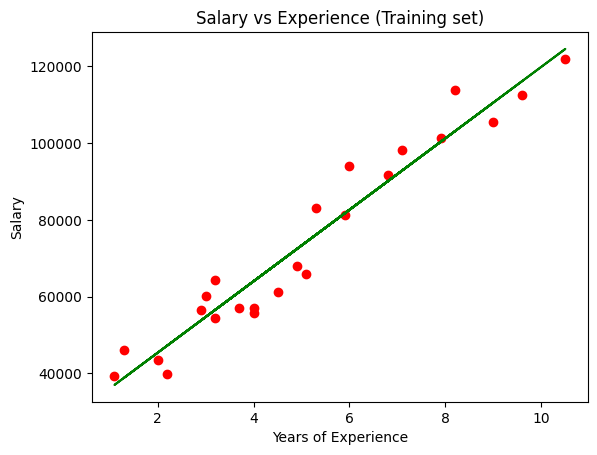

In [ ]:
plt.scatter(X_train,y_train,color='red')
plt.plot(X_train,regressor.predict(X_train),color='green')
plt.title('Salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

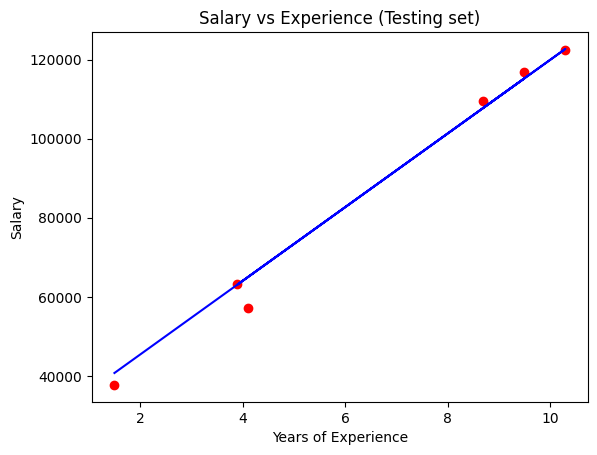

In [ ]:
plt.scatter(X_test,y_test,color='red')
plt.plot(X_test,y_pred,color='blue')
plt.title('Salary vs Experience (Testing set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

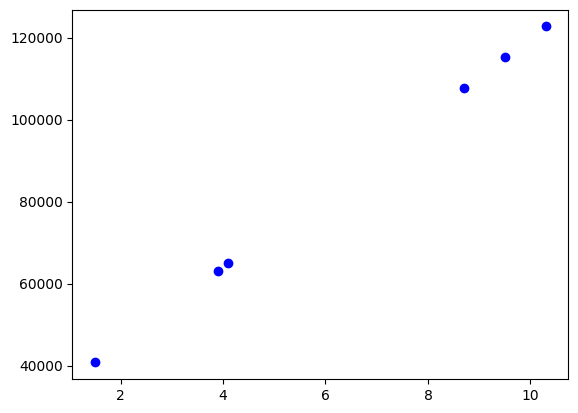

In [ ]:
plt.scatter(X_test,y_pred,color='blue')
plt.show()

## 8. Đánh giá mô hình

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error


In [ ]:
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print('MRSE:',np.sqrt(mean_squared_error(y_test,y_pred)))
print('R2:',r2_score(y_test,y_pred))


12823412.298126549
2446.1723690465055
MRSE: 3580.979237321343
R2: 0.988169515729126
